<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/%20Chapter-4-Nonholonomic-Mechanics/Untitled162.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Skating**



We illustrate the closed form formula for the skating solution for the boundary conditions
$$
(\phi_0, x_0, y_0) = (0,0,0),
\qquad
(\phi_1, x_1, y_1) = \left(\frac{\pi}{2}, 1, 1\right).
$$


Epoch 0: Loss=92.7131, r=1.001, alpha=0.001
Epoch 200: Loss=46.0810, r=1.188, alpha=0.181
Epoch 400: Loss=23.0606, r=1.350, alpha=0.331
Epoch 600: Loss=10.5426, r=1.482, alpha=0.445
Epoch 800: Loss=4.4466, r=1.585, alpha=0.525
Epoch 1000: Loss=1.7777, r=1.661, alpha=0.577
Epoch 1200: Loss=0.7409, r=1.714, alpha=0.607
Epoch 1400: Loss=0.3774, r=1.748, alpha=0.624
Epoch 1600: Loss=0.2605, r=1.769, alpha=0.630
Epoch 1800: Loss=0.2233, r=1.782, alpha=0.630
Epoch 2000: Loss=0.2079, r=1.791, alpha=0.626
Epoch 2200: Loss=0.1973, r=1.796, alpha=0.619
Epoch 2400: Loss=0.1875, r=1.801, alpha=0.611
Epoch 2600: Loss=0.1777, r=1.806, alpha=0.603
Epoch 2800: Loss=0.1680, r=1.812, alpha=0.593
Epoch 3000: Loss=0.1583, r=1.817, alpha=0.584
Epoch 3200: Loss=0.1487, r=1.824, alpha=0.574
Epoch 3400: Loss=0.1391, r=1.830, alpha=0.564
Epoch 3600: Loss=0.1298, r=1.837, alpha=0.553
Epoch 3800: Loss=0.1206, r=1.845, alpha=0.543
Epoch 4000: Loss=0.1117, r=1.853, alpha=0.532
Epoch 4200: Loss=0.1030, r=1.862, alp

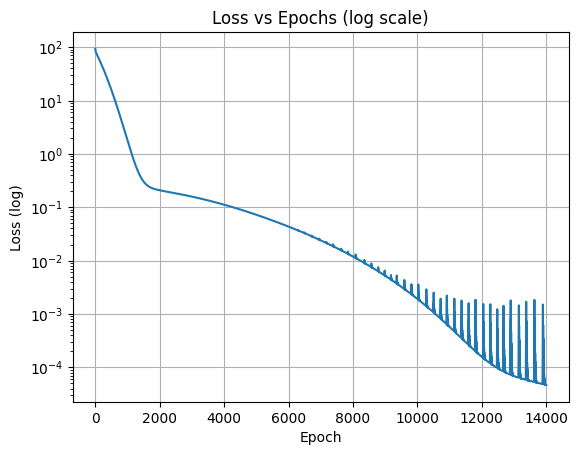

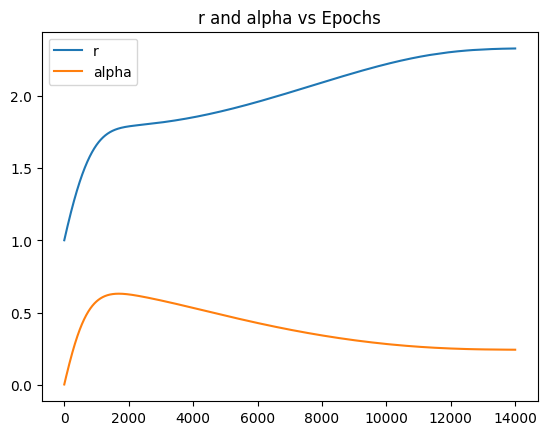

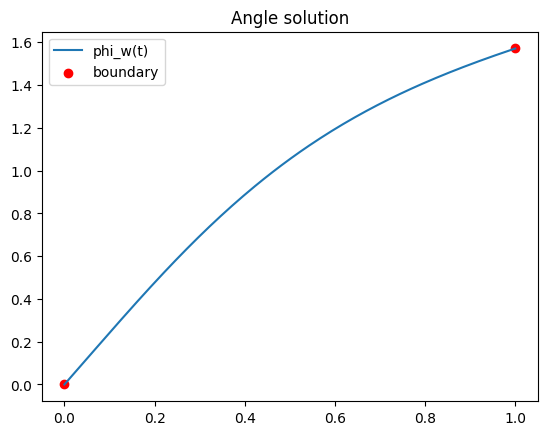

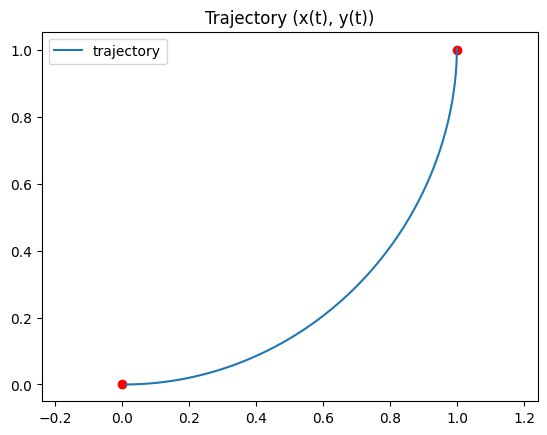

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Boundary conditions
# -----------------------------
phi0, phi1 = 0.0, np.pi/2
x0, y0 = 0.0, 0.0
x1, y1 = 1.0, 1.0

# -----------------------------
# Neural network for nn_theta
# -----------------------------
def build_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(32, activation='tanh'),
        tf.keras.layers.Dense(32, activation='tanh'),
        tf.keras.layers.Dense(1)
    ])

net = build_model()

# Trainable scalars r and alpha
r = tf.Variable(1.0, dtype=tf.float32)
alpha = tf.Variable(0.0, dtype=tf.float32)

# -----------------------------
# Hard constraint embedding
# -----------------------------
def phi_w(t):
    nn = net(t)
    return (1-t)*phi0 + t*phi1 + t*(1-t)*nn

# -----------------------------
# Compute derivatives
# -----------------------------
def compute_derivatives(t):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(t)
        with tf.GradientTape() as tape1:
            tape1.watch(t)
            phi = phi_w(t)
        dphi = tape1.gradient(phi, t)
    ddphi = tape2.gradient(dphi, t)
    return phi, dphi, ddphi

# -----------------------------
# Loss function
# -----------------------------
def loss_fn(t):
    phi, dphi, ddphi = compute_derivatives(t)

    # ODE loss
    ode = ddphi + 0.5 * r**2 * tf.sin(2*phi - alpha)
    L_ode = tf.reduce_mean(ode**2)

    # Compute x(1), y(1) via trapezoidal integration
    integrand_x = r * tf.cos(phi - alpha) * tf.cos(phi)
    integrand_y = r * tf.cos(phi - alpha) * tf.sin(phi)

    x_end = x0 + tf.reduce_mean(integrand_x)
    y_end = y0 + tf.reduce_mean(integrand_y)

    L_bx = (x1 - x_end)**2
    L_by = (y1 - y_end)**2

    return L_ode + 200.0*L_bx + 100.0*L_by, L_ode, L_bx, L_by

# -----------------------------
# Training
# -----------------------------
optimizer = tf.keras.optimizers.Adam(1e-3)

epochs = 14000
t_train = tf.linspace(0.0, 1.0, 100)[:, None]

loss_hist = []
r_hist = []
alpha_hist = []

for ep in range(epochs):
    with tf.GradientTape() as tape:
        L, Lode, Lbx, Lby = loss_fn(t_train)

    grads = tape.gradient(L, net.trainable_variables + [r, alpha])
    optimizer.apply_gradients(zip(grads, net.trainable_variables + [r, alpha]))

    loss_hist.append(L.numpy())
    r_hist.append(r.numpy())
    alpha_hist.append(alpha.numpy())

    if ep % 200 == 0:
        print(f"Epoch {ep}: Loss={L.numpy():.4f}, r={r.numpy():.3f}, alpha={alpha.numpy():.3f}")

# -----------------------------
# Evaluation
# -----------------------------
t_test = tf.linspace(0.0, 1.0, 200)[:, None]
phi_pred = phi_w(t_test).numpy().flatten()

# reconstruct x,y
phi_tf = phi_w(t_test)
x_curve = x0 + tf.cumsum(r * tf.cos(phi_tf - alpha) * tf.cos(phi_tf), axis=0) / len(t_test)
y_curve = y0 + tf.cumsum(r * tf.cos(phi_tf - alpha) * tf.sin(phi_tf), axis=0) / len(t_test)

x_curve = x_curve.numpy().flatten()
y_curve = y_curve.numpy().flatten()

# -----------------------------
# Plots
# -----------------------------


# Loss (log scale)
plt.figure()
plt.semilogy(loss_hist)
plt.title("Loss vs Epochs (log scale)")
plt.xlabel("Epoch")
plt.ylabel("Loss (log)")
plt.grid(True)
plt.show()

# r and alpha
plt.figure()
plt.plot(r_hist, label="r")
plt.plot(alpha_hist, label="alpha")
plt.legend()
plt.title("r and alpha vs Epochs")
plt.show()

# phi(t)
plt.figure()
plt.plot(t_test, phi_pred, label="phi_w(t)")
plt.scatter([0,1],[phi0,phi1], color='red', label="boundary")
plt.title("Angle solution")
plt.legend()
plt.show()

# trajectory
plt.figure()
plt.plot(x_curve, y_curve, label="trajectory")
plt.scatter([x0,x1],[y0,y1], color='red')
plt.title("Trajectory (x(t), y(t))")
plt.axis('equal')
plt.legend()
plt.show()

# **Soft penalty implementation**

 Now we pursue an implementation which uses a soft constraint to implement the nonholonomic constraints as follows.  First we consider a neural network to learn the solutions having the boundary conditions embedded in the network as
\begin{align*}
  x_{\theta}(t) &= (1-t) x_0 + t x_1 + t(1-t) nn^1_{\theta}(t) \\
 y_{\theta}(t) &= (1-t) y_0 + t y_1 + t(1-t) nn^2_{\theta}(t) \\
  \phi_{\theta}(t) &= (1-t) \phi_0 + t \phi_1 + t(1-t) nn^3_{\theta}(t),
\end{align*}
with $nn^j_{\theta}$ free feedforward one-dimensional neural networks.

We consider the energy loss
$$ L_{energy}(\theta) = \int_0^1 [ \Big( \dot x_{\theta}(t) \cos \phi(t) + \dot y_{\theta}(t) \sin \phi_{\theta}(t)  \Big)^2 + \dot \phi_{\theta}(t)^2 ] \, dt $$
and the constraint loss
$$ L_{constr}(\theta) = \int_0^1 \Big( \dot x_{\theta} \sin \phi_{\theta} - \dot y_{\theta} \cos \phi_{\theta}  \Big)^2 \, dt, $$
which is sued as a penalty constraint in the total loss as
$$ L_{total}(\theta) = L_{energy}(\theta) + \gamma L_{constr}(\theta), $$
with $\gamma>0$ penalty weight. The total loss is minimized by the gradient descent method.

Epoch 0: Loss=20.14660
Epoch 500: Loss=4.90211
Epoch 1000: Loss=4.89831
Epoch 1500: Loss=4.89211
Epoch 2000: Loss=4.88517
Epoch 2500: Loss=4.88205
Epoch 3000: Loss=4.88148
Epoch 3500: Loss=4.88119
Epoch 4000: Loss=4.88074
Epoch 4500: Loss=4.87941


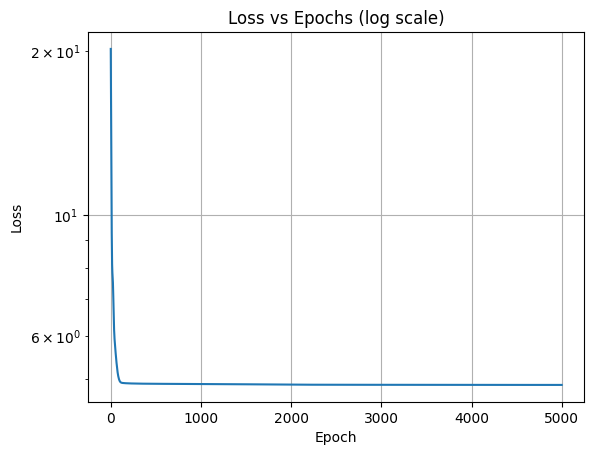

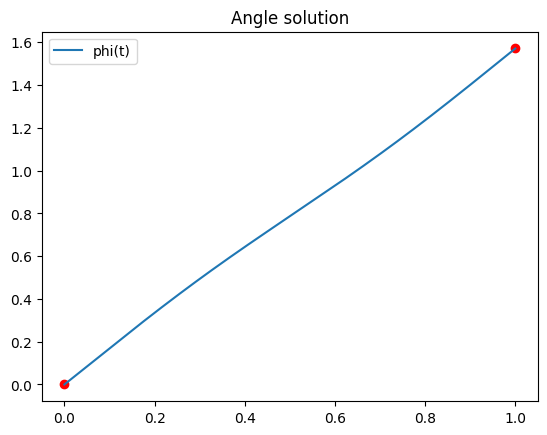

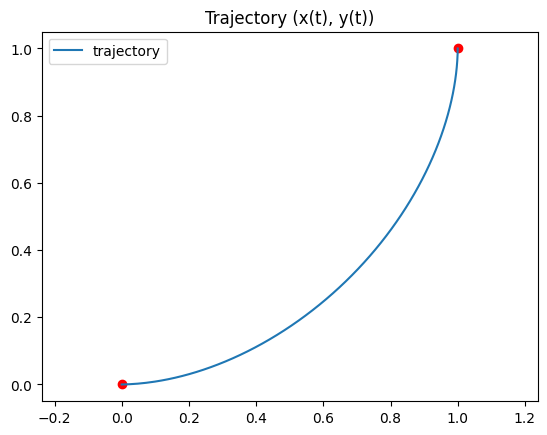

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Boundary conditions
# -----------------------------
phi0, phi1 = 0.0, np.pi/2
x0, y0 = 0.0, 0.0
x1, y1 = 1.0, 1.0

# -----------------------------
# Build networks
# -----------------------------
def make_net():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(32, activation='tanh'),
        tf.keras.layers.Dense(32, activation='tanh'),
        tf.keras.layers.Dense(1)
    ])

net_x = make_net()
net_y = make_net()
net_phi = make_net()

# -----------------------------
# Hard embedding
# -----------------------------
def model_outputs(t):
    x = (1-t)*x0 + t*x1 + t*(1-t)*net_x(t)
    y = (1-t)*y0 + t*y1 + t*(1-t)*net_y(t)
    phi = (1-t)*phi0 + t*phi1 + t*(1-t)*net_phi(t)
    return x, y, phi

# -----------------------------
# Derivatives
# -----------------------------
def derivatives(t):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(t)
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(t)
            x, y, phi = model_outputs(t)
        dx = tape1.gradient(x, t)
        dy = tape1.gradient(y, t)
        dphi = tape1.gradient(phi, t)
    return x, y, phi, dx, dy, dphi

# -----------------------------
# Loss
# -----------------------------
gamma = 50.0

def loss_fn(t):
    x, y, phi, dx, dy, dphi = derivatives(t)

    energy = (dx*tf.cos(phi) + dy*tf.sin(phi))**2 + dphi**2
    L_energy = tf.reduce_mean(energy)

    constr = (dx*tf.sin(phi) - dy*tf.cos(phi))**2
    L_constr = tf.reduce_mean(constr)

    return L_energy + gamma*L_constr

# -----------------------------
# Training
# -----------------------------
opt = tf.keras.optimizers.Adam(1e-3)

epochs = 5000
t_train = tf.linspace(0.0, 1.0, 100)[:, None]

loss_hist = []

for ep in range(epochs):
    with tf.GradientTape() as tape:
        L = loss_fn(t_train)

    vars = (net_x.trainable_variables +
            net_y.trainable_variables +
            net_phi.trainable_variables)

    grads = tape.gradient(L, vars)
    opt.apply_gradients(zip(grads, vars))

    loss_hist.append(L.numpy())

    if ep % 500 == 0:
        print(f"Epoch {ep}: Loss={L.numpy():.5f}")

# -----------------------------
# Evaluation
# -----------------------------
t_test = tf.linspace(0.0, 1.0, 200)[:, None]
x, y, phi = model_outputs(t_test)

x = x.numpy().flatten()
y = y.numpy().flatten()
phi = phi.numpy().flatten()

# -----------------------------
# Plots
# -----------------------------

# Loss (log scale)
plt.figure()
plt.semilogy(loss_hist)
plt.title("Loss vs Epochs (log scale)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# phi(t)
plt.figure()
plt.plot(t_test, phi, label="phi(t)")
plt.scatter([0,1], [phi0,phi1], color='red')
plt.title("Angle solution")
plt.legend()
plt.show()

# trajectory
plt.figure()
plt.plot(x, y, label="trajectory")
plt.scatter([x0,x1], [y0,y1], color='red')
plt.title("Trajectory (x(t), y(t))")
plt.axis('equal')
plt.legend()
plt.show()

# **Hard embedding**

The nonholonomic constraint is enforced exactly (hard embedding) by defining
\begin{align*}
x_{\theta}(t) &= x_0 + \int_0^t u_{\theta}(s)\cos\phi_{\theta}(s)\, ds, \\
y_{\theta}(t) &= y_0 + \int_0^t u_{\theta}(s)\sin\phi_{\theta}(s)\, ds.
\end{align*}

We enforce the boundary conditions for the angle via

$$
\phi_{\theta}(t)
= (1-t)\phi_0 + t\phi_1 + t(1-t)\, f_{\theta}(t).
$$

The total loss functional consists of the energy together with soft penalty terms enforcing the terminal conditions for $x(t)$ and $y(t)$:
$$
L_{\mathrm{total}}(\theta)
= \frac{1}{2}\int_0^1 \Big(u_{\theta}(s)^2 + \dot{\phi}_{\theta}(s)^2\Big)\, ds
+ \beta_1 \big|x_{\theta}(1) - x_1\big|^2
+ \beta_2 \big|y_{\theta}(1) - y_1\big|^2,
$$
where $\beta_1, \beta_2 > 0$ are penalty parameters.

Epoch 0: Loss=329.877045
Epoch 50: Loss=5.970030
Epoch 100: Loss=5.496764
Epoch 150: Loss=5.487563
Epoch 200: Loss=5.477378
Epoch 250: Loss=5.466027
Epoch 300: Loss=5.453660
Epoch 350: Loss=5.440444
Epoch 400: Loss=5.426511
Epoch 450: Loss=5.411975


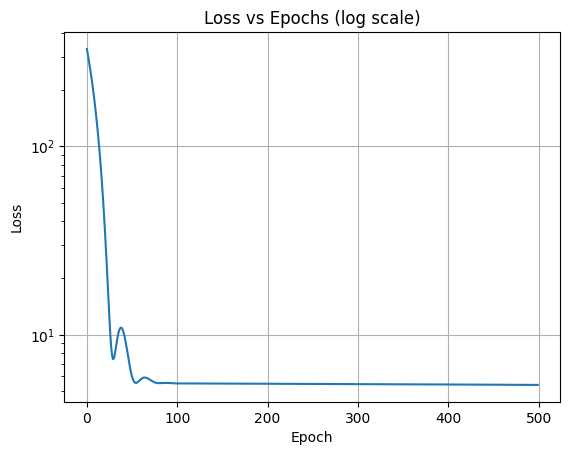

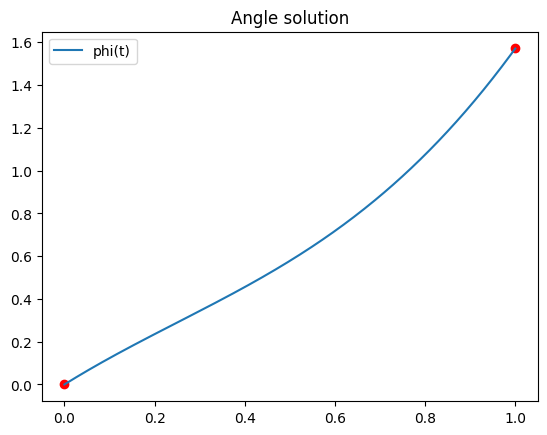

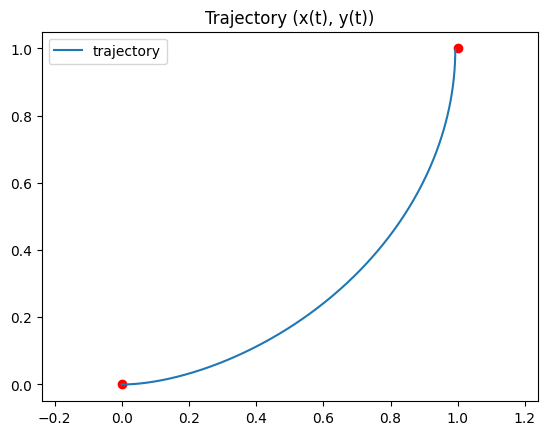

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Boundary conditions
# -----------------------------
phi0, phi1 = 0.0, np.pi/2
x0, y0 = 0.0, 0.0
x1, y1 = 1.0, 1.0

# -----------------------------
# Neural networks
# -----------------------------
def make_net():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(32, activation='tanh'),
        tf.keras.layers.Dense(32, activation='tanh'),
        tf.keras.layers.Dense(1)
    ])

net_u = make_net()
net_f = make_net()

# -----------------------------
# Hard embedding
# -----------------------------
def phi_theta(t):
    return (1 - t)*phi0 + t*phi1 + t*(1 - t)*net_f(t)

def u_theta(t):
    return net_u(t)

# -----------------------------
# Trapezoidal integration
# -----------------------------
def integrate_trapz(y, t):
    dt = t[1:] - t[:-1]
    return tf.reduce_sum(0.5 * (y[:-1] + y[1:]) * dt)

# -----------------------------
# Compute x(t), y(t)
# -----------------------------
def compute_xy(t):
    phi = phi_theta(t)
    u = u_theta(t)

    integrand_x = u * tf.cos(phi)
    integrand_y = u * tf.sin(phi)

    x_vals = []
    y_vals = []

    for i in range(len(t)):
        x_i = x0 + integrate_trapz(integrand_x[:i+1], t[:i+1])
        y_i = y0 + integrate_trapz(integrand_y[:i+1], t[:i+1])
        x_vals.append(x_i)
        y_vals.append(y_i)

    x = tf.stack(x_vals)
    y = tf.stack(y_vals)

    return x, y, phi, u

# -----------------------------
# Derivatives
# -----------------------------
def compute_dphi(t):
    with tf.GradientTape() as tape:
        tape.watch(t)
        phi = phi_theta(t)
    dphi = tape.gradient(phi, t)
    return dphi

# -----------------------------
# Loss function
# -----------------------------
beta1, beta2 = 300.0, 100.0

def loss_fn(t):
    x, y, phi, u = compute_xy(t)
    dphi = compute_dphi(t)

    # Energy loss
    L_energy = integrate_trapz(u**2 + dphi**2, t)

    # Boundary penalties
    L_bx = (x[-1] - x1)**2
    L_by = (y[-1] - y1)**2

    return L_energy + beta1*L_bx + beta2*L_by

# -----------------------------
# Training
# -----------------------------
optimizer = tf.keras.optimizers.Adam(1e-3)

epochs = 500
t_train = tf.linspace(0.0, 1.0, 200)[:, None]

loss_hist = []

for ep in range(epochs):
    with tf.GradientTape() as tape:
        L = loss_fn(t_train)

    variables = net_u.trainable_variables + net_f.trainable_variables
    grads = tape.gradient(L, variables)
    optimizer.apply_gradients(zip(grads, variables))

    loss_val = L.numpy().item()
    loss_hist.append(loss_val)

    if ep % 50 == 0:
        print(f"Epoch {ep}: Loss={loss_val:.6f}")

# -----------------------------
# Evaluation
# -----------------------------
t_test = tf.linspace(0.0, 1.0, 300)[:, None]
x, y, phi, u = compute_xy(t_test)

x = x.numpy().flatten()
y = y.numpy().flatten()
phi = phi.numpy().flatten()

# -----------------------------
# Plots
# -----------------------------

# Loss (log scale)
plt.figure()
plt.semilogy(loss_hist)
plt.title("Loss vs Epochs (log scale)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Angle phi(t)
plt.figure()
plt.plot(t_test, phi, label="phi(t)")
plt.scatter([0,1], [phi0,phi1], color='red')
plt.title("Angle solution")
plt.legend()
plt.show()

# Trajectory (x,y)
plt.figure()
plt.plot(x, y, label="trajectory")
plt.scatter([x0,x1], [y0,y1], color='red')
plt.title("Trajectory (x(t), y(t))")
plt.axis('equal')
plt.legend()
plt.show()